# AI Business Value Notebook

### This Notebook serves as the analysis area for determining the business outcomes associated with adopting AI

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sqlite3


In [7]:
#Create dataframes
df_industry = pd.read_csv("../Data/ai_industry_summary.csv")  #

df_company = pd.read_csv("../Data/ai_company_adoption.csv") 

df_country = pd.read_csv("../Data/country_ai_index.csv")

In [8]:
# I want to merge country to company for the correlation
ai_analysis = df_company.merge(
    df_country,
    on=["country", "region"],
    how="left"
)

ai_analysis.head()

,response_id,company_id,survey_year,quarter,country,region,industry,company_size,num_employees,annual_revenue_usd_millions,...,innovation_score,customer_satisfaction,survey_source,data_collection_method,gdp_per_capita,internet_penetration,digital_maturity_index,country_ai_policy,ai_patent_filings_2024,ai_researchers_per_million
0,1,COMP-00001,2023,Q1,Italy,Europe,Education,Startup,57,48.31,...,53,5.20,WEF Survey,API Scrape,39436.63,86.01,75.65,Moderate,2234,296.83
1,2,COMP-00001,2023,Q2,Italy,Europe,Education,Startup,57,48.31,...,51,6.98,McKinsey Report,Phone Interview,39436.63,86.01,75.65,Moderate,2234,296.83
2,3,COMP-00001,2023,Q3,Italy,Europe,Education,Startup,57,48.31,...,40,4.12,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
3,4,COMP-00001,2023,Q4,Italy,Europe,Education,Startup,57,48.31,...,51,5.72,Internal Corporate Survey,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83
4,5,COMP-00001,2024,Q1,Italy,Europe,Education,Startup,57,48.31,...,43,6.31,McKinsey Report,Research Compilation,39436.63,86.01,75.65,Moderate,2234,296.83


In [9]:
#Gathering business success parameters for correlation and splitting them into factors impacted and driving factors
success_factors = df_company[
    [
        # Success measures
        "ai_maturity_score",
        "productivity_change_percent",
        "ai_failure_rate",
        "revenue_growth_percent",
        "customer_satisfaction",

        # Possible drivers
        "years_using_ai",
        "ai_training_hours",
        "ai_budget_percentage",
        "num_ai_tools_used",
        "ai_investment_per_employee",
        "regulatory_compliance_score",
        "ai_risk_management_score"
    ]
]

In [10]:
# Playing with variation on correlation - Isolation occurs below success_factors correlation
business_success = df_company[
    [
        # outcomes
        "productivity_change_percent",
        "cost_reduction_percent",
        "revenue_growth_percent",
        "innovation_score",
        "customer_satisfaction",
        "employee_satisfaction_score",

        # possible drivers
        "ai_adoption_rate",
        "ai_maturity_score",
        "ai_training_hours",
        "ai_budget_percentage",
        "ai_investment_per_employee",
        "num_ai_tools_used",
        "ai_projects_active",
        "ai_risk_management_score"
    ]
]

business_corr = business_success.corr()

In [11]:
# setting correlation to a variable for easy access
success_corr = success_factors.corr()
#print out the correlation
success_corr

,ai_maturity_score,productivity_change_percent,ai_failure_rate,revenue_growth_percent,customer_satisfaction,years_using_ai,ai_training_hours,ai_budget_percentage,num_ai_tools_used,ai_investment_per_employee,regulatory_compliance_score,ai_risk_management_score
ai_maturity_score,1.000000,0.737314,-0.697749,0.403190,0.458789,0.155064,0.821696,0.819248,0.454016,0.297108,0.010925,0.445840
productivity_change_percent,0.737314,1.000000,-0.593667,0.476247,0.569821,0.116494,0.633740,0.604105,0.364423,0.218707,0.010039,0.328775
ai_failure_rate,-0.697749,-0.593667,1.000000,-0.322041,-0.434765,-0.098316,-0.739570,-0.527048,-0.351571,-0.194754,-0.003887,-0.312925
revenue_growth_percent,0.403190,0.476247,-0.322041,1.000000,0.277019,0.072800,0.347841,0.340629,0.216696,0.121861,0.009992,0.180570
customer_satisfaction,0.458789,0.569821,-0.434765,0.277019,1.000000,0.068908,0.415638,0.368443,0.226932,0.132962,0.007297,0.204855
years_using_ai,0.155064,0.116494,-0.098316,0.072800,0.068908,1.000000,0.134539,0.138527,0.118055,0.043809,0.005332,0.065638
ai_training_hours,0.821696,0.633740,-0.739570,0.347841,0.415638,0.134539,1.000000,0.560236,0.393811,0.204215,0.008030,0.365538
ai_budget_percentage,0.819248,0.604105,-0.527048,0.340629,0.368443,0.138527,0.560236,1.000000,0.400556,0.350236,0.010780,0.367073
num_ai_tools_used,0.454016,0.364423,-0.351571,0.216696,0.226932,0.118055,0.393811,0.400556,1.000000,0.143924,0.006523,0.201708
ai_investment_per_employee,0.297108,0.218707,-0.194754,0.121861,0.132962,0.043809,0.204215,0.350236,0.143924,1.000000,0.001123,0.136389


The next few cells will isolate correlation results out of the larger correlation analysis conducted above

In [12]:
# Isolating ai_maturity_score against all other columns and sorting highest to lowest. 
# Strong positive correlation between AI maturity and training hours, budget, and productivity changes
success_corr["ai_maturity_score"].sort_values(
    ascending=False
)

ai_maturity_score              1.000000
ai_training_hours              0.821696
ai_budget_percentage           0.819248
productivity_change_percent    0.737314
customer_satisfaction          0.458789
num_ai_tools_used              0.454016
ai_risk_management_score       0.445840
revenue_growth_percent         0.403190
ai_investment_per_employee     0.297108
years_using_ai                 0.155064
regulatory_compliance_score    0.010925
ai_failure_rate               -0.697749
Name: ai_maturity_score, dtype: float64

In [13]:
# Isolating productivity change to see highest correlation. AI maturity, training, and then budget
success_corr["productivity_change_percent"].sort_values(
    ascending=False
)

productivity_change_percent    1.000000
ai_maturity_score              0.737314
ai_training_hours              0.633740
ai_budget_percentage           0.604105
customer_satisfaction          0.569821
revenue_growth_percent         0.476247
num_ai_tools_used              0.364423
ai_risk_management_score       0.328775
ai_investment_per_employee     0.218707
years_using_ai                 0.116494
regulatory_compliance_score    0.010039
ai_failure_rate               -0.593667
Name: productivity_change_percent, dtype: float64

In [14]:
# What correlates with productivity - business_corr variation revealed that adoption rate is also strongly correlated. 
#Productivity is only mildly associated with cost reduction
business_corr[
    "productivity_change_percent"
].sort_values(
    ascending=False
)

productivity_change_percent    1.000000
ai_maturity_score              0.737314
ai_adoption_rate               0.674973
ai_training_hours              0.633740
ai_budget_percentage           0.604105
customer_satisfaction          0.569821
ai_projects_active             0.566833
revenue_growth_percent         0.476247
innovation_score               0.405074
num_ai_tools_used              0.364423
cost_reduction_percent         0.345855
ai_risk_management_score       0.328775
employee_satisfaction_score    0.290436
ai_investment_per_employee     0.218707
Name: productivity_change_percent, dtype: float64

In [15]:
# What correlates with cost reduction - Strongest correlation is AI adoption rate and even that is only mid level correlation
# Revenue and cost saving fall far behind productivity increases
business_corr[
    "cost_reduction_percent"
].sort_values(
    ascending=False
)

cost_reduction_percent         1.000000
ai_adoption_rate               0.404302
ai_maturity_score              0.386162
productivity_change_percent    0.345855
ai_budget_percentage           0.328713
ai_training_hours              0.328314
ai_projects_active             0.289453
innovation_score               0.222638
num_ai_tools_used              0.218866
customer_satisfaction          0.205888
revenue_growth_percent         0.190982
ai_risk_management_score       0.171646
employee_satisfaction_score    0.147959
ai_investment_per_employee     0.117579
Name: cost_reduction_percent, dtype: float64

In [16]:
# What correlates with innovation?
business_corr[
    "innovation_score"
].sort_values(
    ascending=False
)

innovation_score               1.000000
ai_maturity_score              0.531790
ai_adoption_rate               0.509864
ai_budget_percentage           0.445472
ai_training_hours              0.444496
ai_projects_active             0.412083
productivity_change_percent    0.405074
num_ai_tools_used              0.274924
customer_satisfaction          0.248808
ai_risk_management_score       0.236262
revenue_growth_percent         0.230596
cost_reduction_percent         0.222638
employee_satisfaction_score    0.203174
ai_investment_per_employee     0.161687
Name: innovation_score, dtype: float64

In [17]:
# Looking at average business outcomes by AI adoption stage
# Group companies by ai maturity and calculates mean on business outcomes
business_outcomes = (
    df_company
    .groupby("ai_adoption_stage")
    [[
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]]
    .mean()
)

business_outcomes

,productivity_change_percent,revenue_growth_percent,cost_reduction_percent
ai_adoption_stage,,,
full,19.792315,10.491941,8.588315
none,2.391995,0.500773,2.188411
partial,12.026603,6.149891,5.770517
pilot,6.165857,2.893164,3.757529


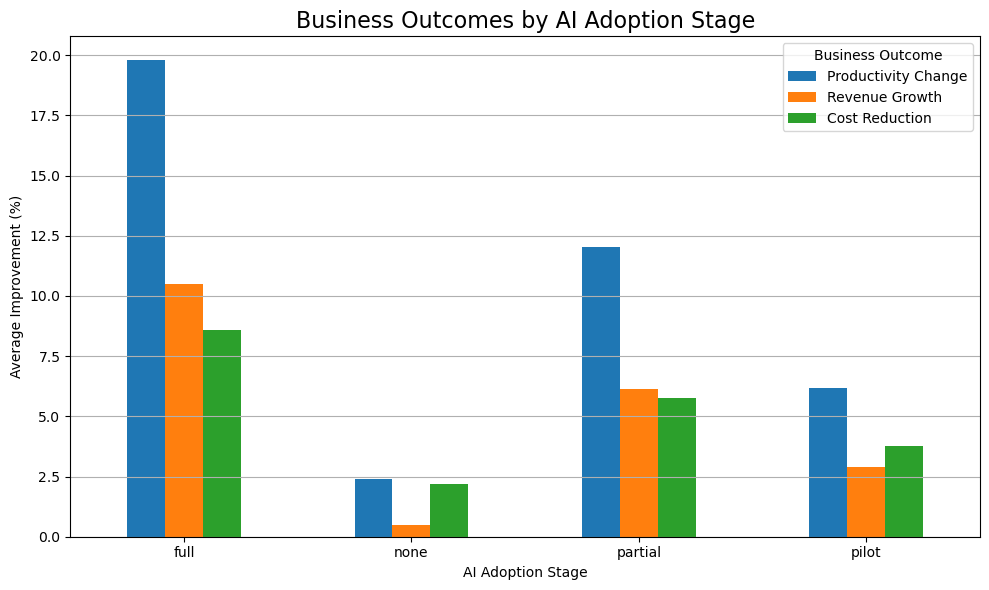

In [18]:
#Initial attempt at plot of business outcomes - cleaner version below

import matplotlib.pyplot as plt

business_outcomes.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Business Outcomes by AI Adoption Stage",fontsize=16)

plt.xlabel("AI Adoption Stage")

plt.ylabel("Average Improvement (%)")

plt.xticks(rotation=0)

plt.legend(
    ["Productivity Change",
        "Revenue Growth",
        "Cost Reduction"
    ],title="Business Outcome")

plt.grid(
    axis="y", #makes just y lines plotalpha=.3
)

plt.tight_layout()
plt.show()

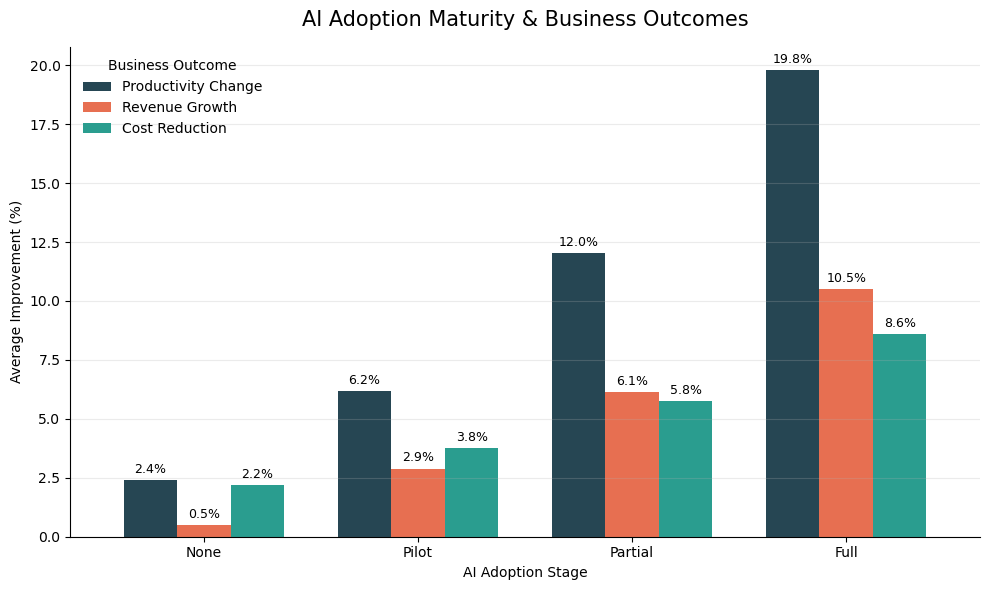

In [25]:
# # This is the improved and final version of the chart above. 


# # Order adoption maturity stages
stage_order = ["none", "pilot", "partial", "full"]

# # Reorders the adoption stages from lowest to highest - works because .loc is able to preserve order of stage_order
business_outcomes = business_outcomes.loc[stage_order] 

# # Rename columns for cleaner labels
business_outcomes_clean = business_outcomes.rename(
    columns={
        "productivity_change_percent": "Productivity Change",
        "revenue_growth_percent": "Revenue Growth",
        "cost_reduction_percent": "Cost Reduction"
    }
)

# # Colors of bars
colors = [
    "#264653",   
    "#E76F51",   
    "#2A9D8F"    
]

fig, ax = plt.subplots(
    figsize=(10, 6)
    )

# # Grouped bar chart
business_outcomes_clean.plot(
    kind="bar",
    ax=ax,
    color=colors,
    width=0.75
)

# # Percentage labels - loop through each group of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%", # %% displays the actual percent symbol
        padding=3,
        fontsize=9
)

# # Title and labels
ax.set_title(
    "AI Adoption Maturity & Business Outcomes",
    fontsize=15,
    pad=15
)

ax.set_xlabel("AI Adoption Stage")

ax.set_ylabel("Average Improvement (%)")

# # Clean x-axis labels
ax.set_xticklabels(
    [
        "None",
        "Pilot",
        "Partial",
        "Full"
    ],
    rotation=0
)

# # Move legend 
ax.legend(
    title="Business Outcome",
    frameon=False,
    loc="upper left"
)

# # Grid formatting
ax.grid(
    axis="y", #Include only the y axis lines
    alpha=0.25
)

# # Remove borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# # Save 
plt.savefig(
    "business_outcomes_by_ai_stage.png",
    dpi=300, #Image resolution
    bbox_inches="tight" #Trims extra whitespace
)
plt.show()

In [33]:
from scipy.stats import pearsonr

r, p = pearsonr(
    df_company["ai_maturity_score"],
    df_company["productivity_change_percent"]
)

print("Correlation:", r)
print("P-value:", p)

Correlation: 0.7373138002177632
P-value: 0.0


The next few cells set up for histogram analysis of how ai maturity is distributed. Need to go back and evaluate use case. 

In [20]:
df_company["maturity_group"] = pd.cut(
    df_company["ai_maturity_score"],
    bins=[0,.25,.5,.75,1],
    labels=["Low","Developing","Advanced", "High"]
)

In [21]:
maturity_business = (
    df_company
    .groupby("maturity_group")
    [
        [
            "productivity_change_percent",
            "revenue_growth_percent",
            "cost_reduction_percent"
        ]
    ]
    .mean()
)

C:\Users\patri\AppData\Local\Temp\ipykernel_43708\346655041.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("maturity_group")


The next cell sets up a scatter plot to visualize what other factors are possibly impacting productivity change. Highlights the need for future analysis.

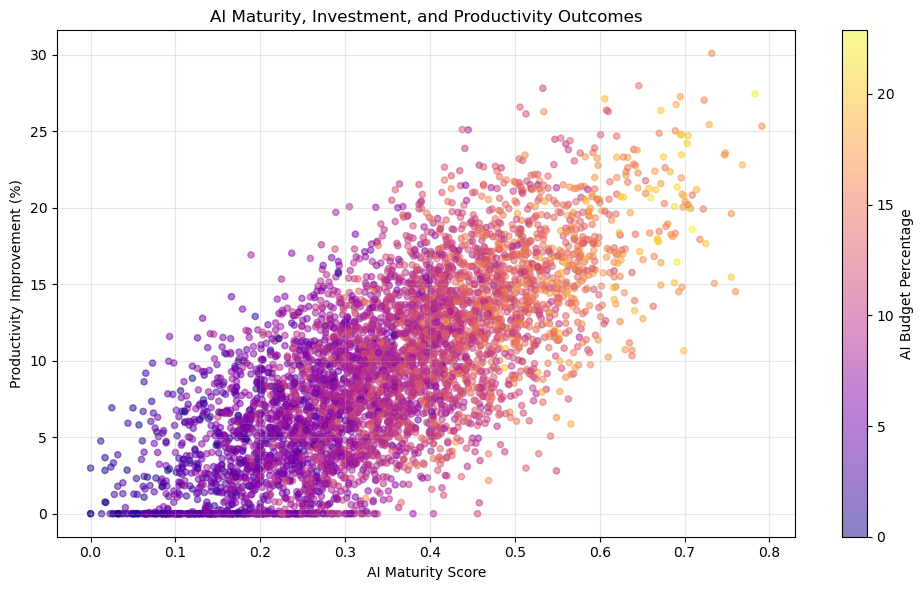

In [22]:
import matplotlib.pyplot as plt

# A random sample of company observations used to improve visualization. Trend hard to identify with dense data
sample = df_company.sample(
    5000,
    random_state=42 # Setting a variable for the randomness we calculate here
)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    sample["ai_maturity_score"], #using the sample data to make the scatter to avoid clutter on the chart
    sample["productivity_change_percent"],
    c=sample["ai_budget_percentage"],
    cmap="plasma", # color scheme
    alpha=.5, # opacity
    s=20 # size of the dot
)

plt.colorbar(scatter,label="AI Budget Percentage")
plt.title("AI Maturity, Investment, and Productivity Outcomes")
plt.xlabel("AI Maturity Score")
plt.ylabel("Productivity Improvement (%)")
plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

Additional analysis was conducted on the survey period and productivity growth by industry. Again tech and finance were ahead, but finance lagged significantly behind tech. 

In [ ]:
#transforming quarter column into month values

quarter_map = {
    "Q1": "01",
    "Q2": "04",
    "Q3": "07",
    "Q4": "10"
}

df_company["survey_period"] = pd.to_datetime(
    df_company["survey_year"].astype(str)+ "-"+ df_company["quarter"].map(quarter_map)+ "-01" #build a date and then turn it into datetime
)

In [ ]:

industry_time = (
    df_company.groupby(["survey_period", "industry"])
    [["ai_adoption_rate", "productivity_change_percent"]].mean().reset_index()
)

industry_time.head()

,survey_period,industry,ai_adoption_rate,productivity_change_percent
0,2023-01-01,Agriculture,31.057278,7.973681
1,2023-01-01,Consulting,30.544369,7.758363
2,2023-01-01,Education,30.875787,7.768215
3,2023-01-01,Finance,34.296522,8.452198
4,2023-01-01,Healthcare,30.852658,7.838714


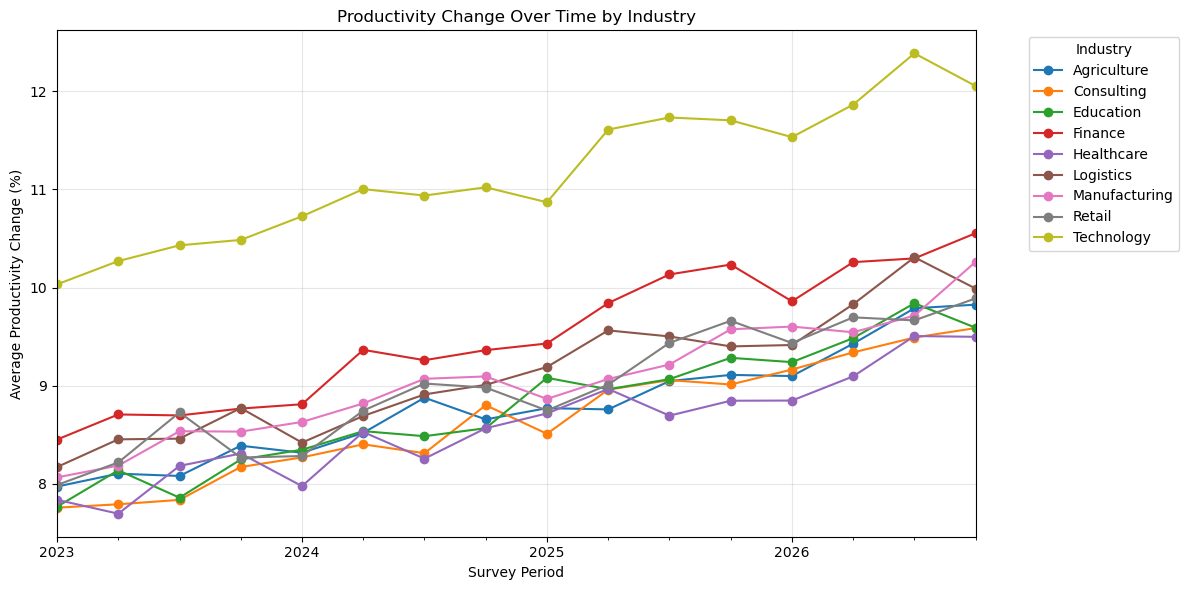

In [29]:

productivity_pivot = industry_time.pivot(
    index="survey_period",
    columns="industry",
    values="productivity_change_percent"
)

productivity_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12,6)
)

plt.title("Productivity Change Over Time by Industry")
plt.xlabel("Survey Period")
plt.ylabel("Average Productivity Change (%)")
plt.grid(alpha=0.3)
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

Interestingly the adoption rate in finance was significantly above the pack, it just did not reflect in productivity in the same way tech did

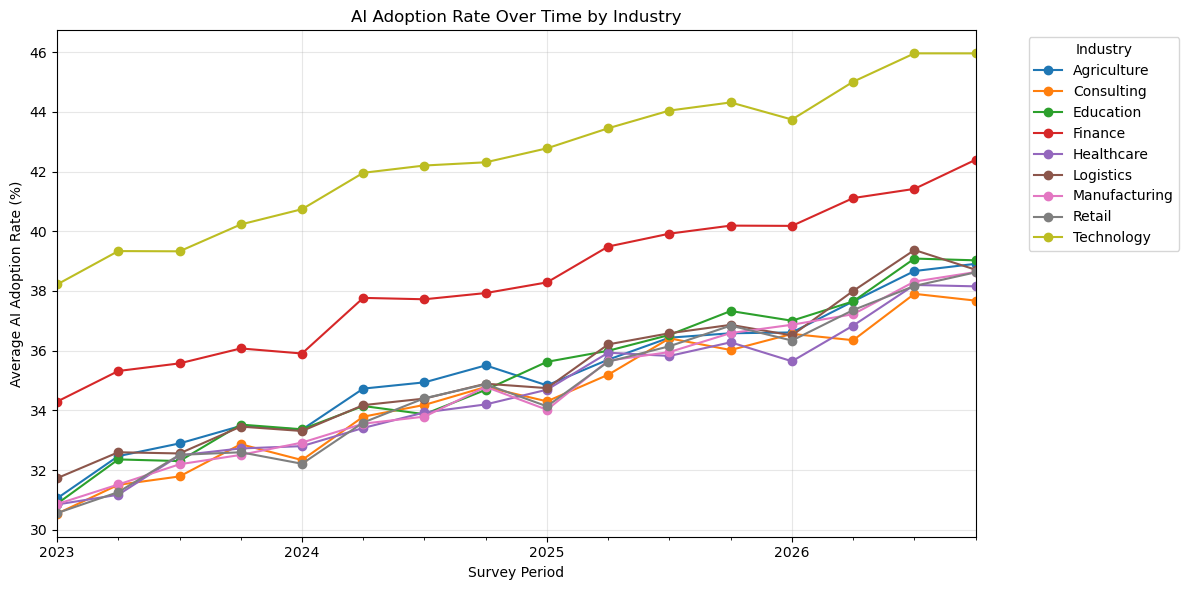

In [32]:
adoption_pivot = industry_time.pivot(
    index="survey_period",
    columns="industry",
    values="ai_adoption_rate"
)

adoption_pivot.plot(
    kind="line",
    marker="o",
    figsize=(12,6)
)

plt.title("AI Adoption Rate Over Time by Industry")
plt.xlabel("Survey Period")
plt.ylabel("Average AI Adoption Rate (%)")
plt.grid(alpha=0.3)
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()